<a href="https://colab.research.google.com/github/diegosantiago92/mvp-dataset/blob/main/notebook_heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 Predição de Doenças Cardíacas com Machine Learning

## Contexto do Problema

As doenças cardiovasculares são a principal causa de morte no mundo, representando cerca de 17,9 milhões de óbitos por ano, segundo a Organização Mundial da Saúde (OMS). A detecção precoce de pacientes com risco elevado é fundamental para a tomada de decisões clínicas e para a redução da mortalidade.

Neste projeto, utilizamos o dataset **Heart Disease** do repositório da UCI (University of California, Irvine), que contém dados clínicos de pacientes e o diagnóstico de presença ou ausência de doença cardíaca. O objetivo é treinar modelos de classificação capazes de prever, a partir de atributos clínicos, se um paciente tem ou não doença cardíaca.

**Atributos do dataset:**
- `age`: idade do paciente (anos)
- `sex`: sexo (1 = masculino, 0 = feminino)
- `cp`: tipo de dor no peito (0–3)
- `trestbps`: pressão arterial em repouso (mm Hg)
- `chol`: colesterol sérico (mg/dl)
- `fbs`: glicemia em jejum > 120 mg/dl (1 = verdadeiro, 0 = falso)
- `restecg`: resultados do eletrocardiograma em repouso (0–2)
- `thalach`: frequência cardíaca máxima atingida
- `exang`: angina induzida por exercício (1 = sim, 0 = não)
- `oldpeak`: depressão ST induzida por exercício
- `slope`: inclinação do segmento ST de pico no exercício
- `ca`: número de vasos principais coloridos por fluoroscopia (0–3)
- `thal`: talassemia (1 = normal, 2 = defeito fixo, 3 = defeito reversível)
- `target`: diagnóstico de doença cardíaca (1 = doença presente, 0 = ausente)

Este é um problema de **classificação binária**: prever se o paciente possui (1) ou não (0) doença cardíaca.

## 1. Instalação e Importação de Bibliotecas

Primeiramente, importamos todas as bibliotecas necessárias para o projeto. Utilizamos o **Scikit-Learn** como biblioteca principal de machine learning, além de **Pandas** para manipulação de dados, **NumPy** para operações numéricas e **Matplotlib/Seaborn** para visualizações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

print('Bibliotecas importadas com sucesso!')
print(f'Versão do scikit-learn: {__import__("sklearn").__version__}')

Bibliotecas importadas com sucesso!
Versão do scikit-learn: 1.6.1


## 2. Carga dos Dados

O dataset é carregado diretamente de uma URL pública do repositório UCI, hospedada no GitHub. Isso permite a execução do notebook sem necessidade de download manual de arquivos.

Após a carga, realizamos uma inspeção inicial para entender a estrutura e a qualidade dos dados.

In [2]:
# Carregando o dataset diretamente via URL (formato CSV do repositório UCI via GitHub)
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df = pd.read_csv(url)

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Dataset carregado com sucesso!
Dimensões: 303 linhas x 14 colunas


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Informações gerais sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Estatísticas descritivas
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [5]:
# Verificando valores ausentes
print('Valores ausentes por coluna:')
print(df.isnull().sum())
print(f'\nTotal de valores ausentes: {df.isnull().sum().sum()}')

Valores ausentes por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total de valores ausentes: 0


In [6]:
# Distribuição da variável alvo
print('Distribuição da variável alvo (target):')
print(df['target'].value_counts())
print(f'\nProporção:')
print(df['target'].value_counts(normalize=True).round(3))

Distribuição da variável alvo (target):
target
1    165
0    138
Name: count, dtype: int64

Proporção:
target
1    0.545
0    0.455
Name: proportion, dtype: float64


## 3. Análise Exploratória dos Dados (EDA)

Antes de treinar os modelos, realizamos uma análise exploratória para entender melhor os dados, identificar padrões e visualizar a distribuição das features em relação ao target.

Esta etapa é fundamental para guiar as decisões de pré-processamento e modelagem.

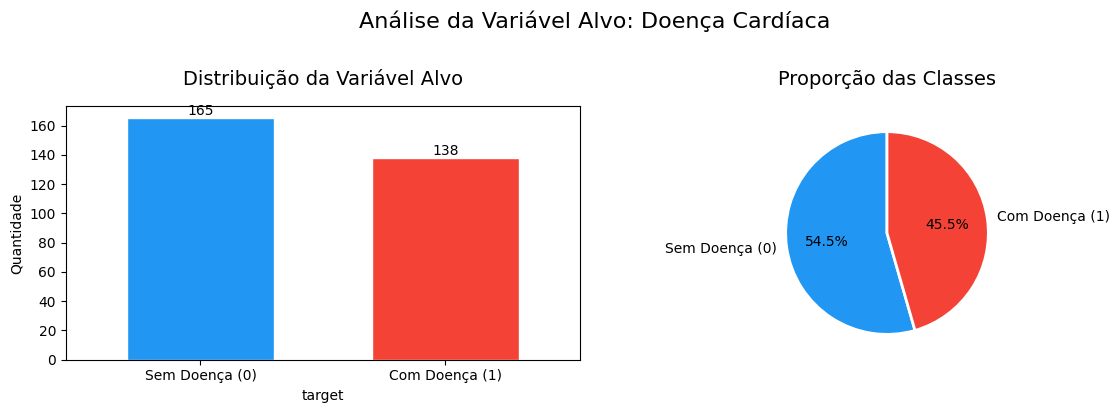

O dataset é razoavelmente balanceado, com ~54% dos pacientes com doença cardíaca.


In [7]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2196F3', '#F44336']
labels = ['Sem Doença (0)', 'Com Doença (1)']

df['target'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.6
)
axes[0].set_title('Distribuição da Variável Alvo', fontsize=14, pad=15)
axes[0].set_xticklabels(labels, rotation=0)
axes[0].set_ylabel('Quantidade')
axes[0].bar_label(axes[0].containers[0])

df['target'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colors, labels=labels,
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporção das Classes', fontsize=14, pad=15)
axes[1].set_ylabel('')

plt.suptitle('Análise da Variável Alvo: Doença Cardíaca', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print('O dataset é razoavelmente balanceado, com ~54% dos pacientes com doença cardíaca.')

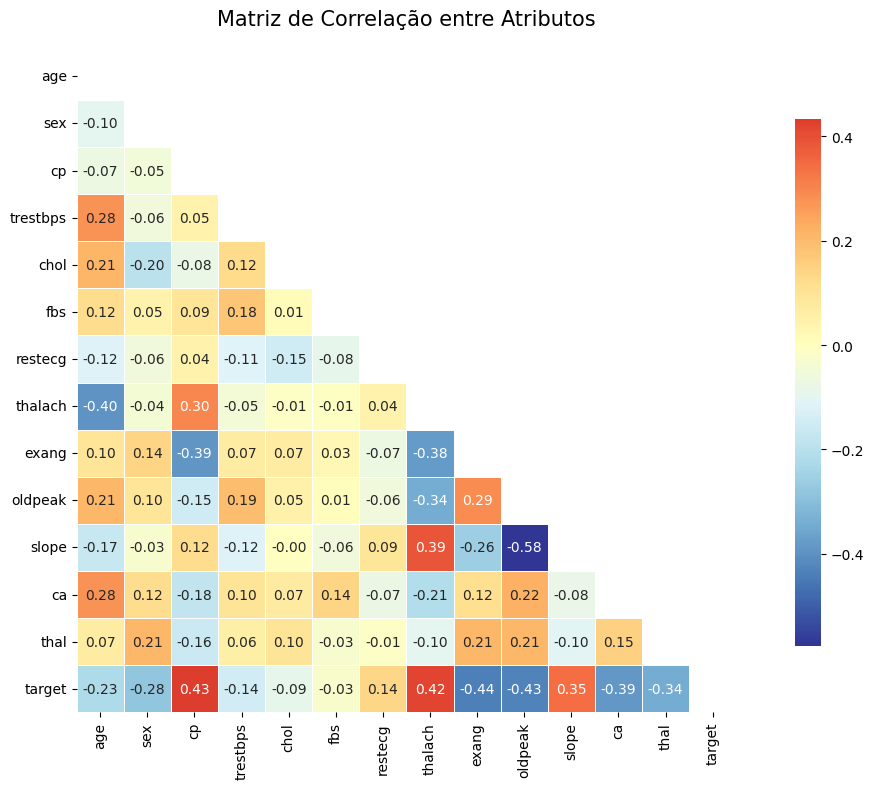

In [8]:
# Correlação entre features e target
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de Correlação entre Atributos', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

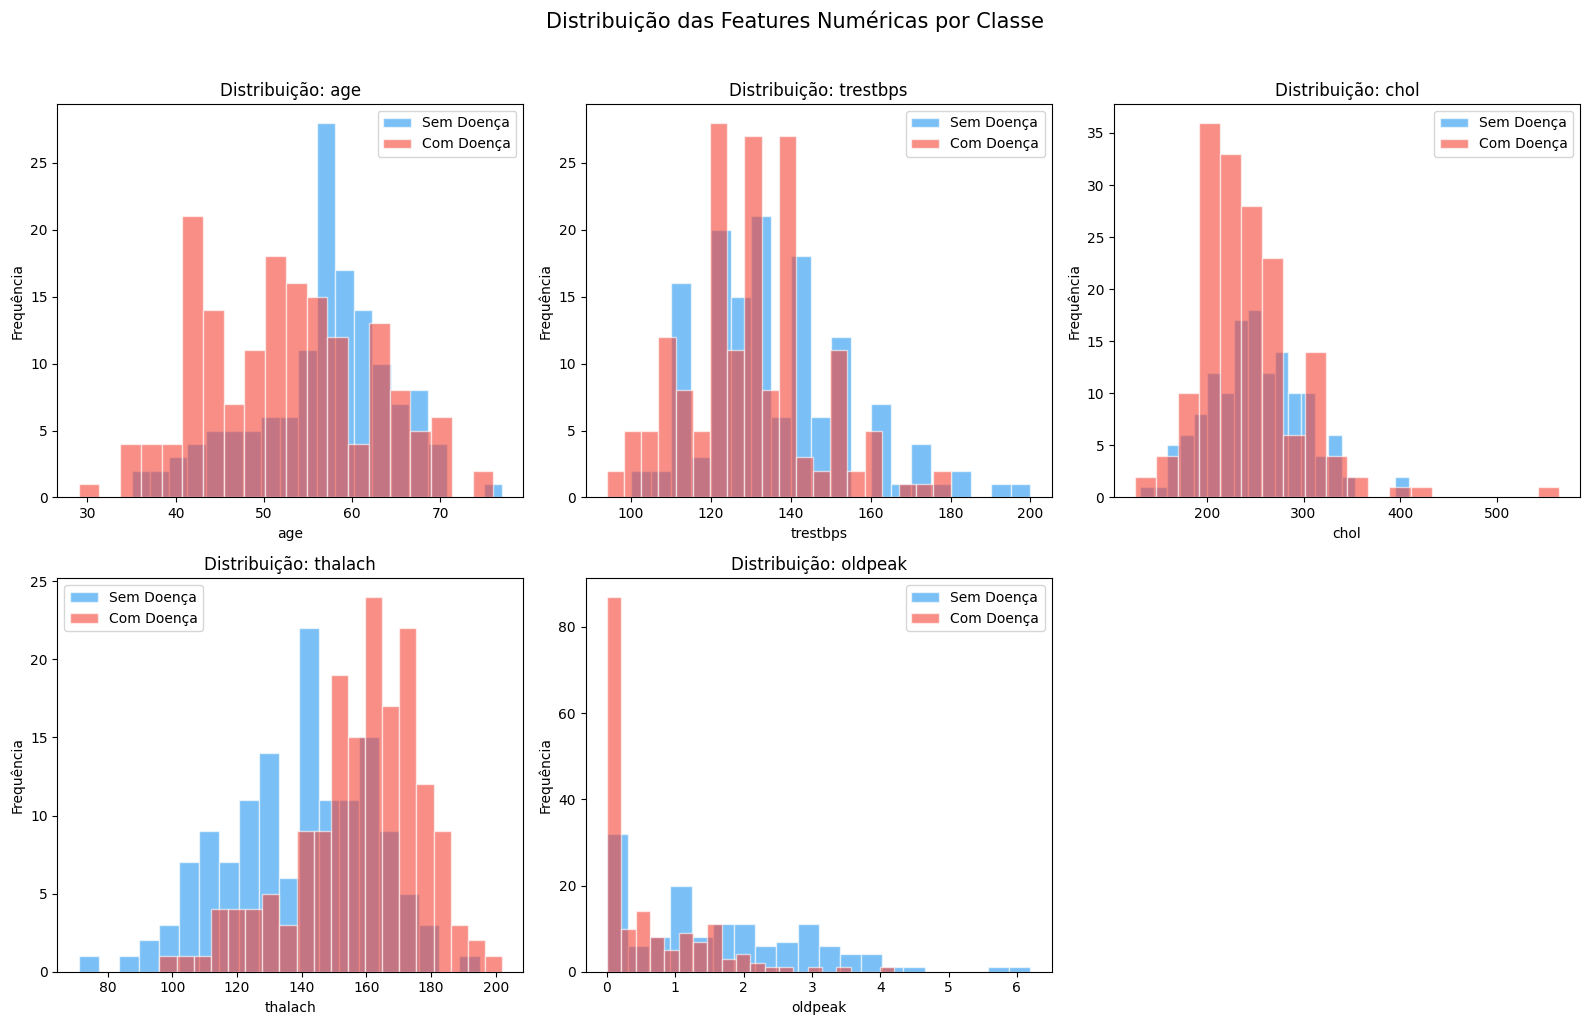

In [9]:
# Distribuição de algumas features numéricas por classe
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    for target_val, color, label in [(0, '#2196F3', 'Sem Doença'), (1, '#F44336', 'Com Doença')]:
        subset = df[df['target'] == target_val][feature]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'Distribuição: {feature}', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Distribuição das Features Numéricas por Classe', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4. Pré-processamento e Separação Treino/Teste

### 4.1 Separação das Features e do Target

Separamos as variáveis preditoras (X) da variável alvo (y). Em seguida, aplicamos o método **holdout** para dividir o dataset em conjuntos de treino (80%) e teste (20%), mantendo a proporção das classes com `stratify=y`.

A escolha de 80/20 é uma prática comum que oferece dados suficientes tanto para treino quanto para uma avaliação confiável.

In [10]:
# Separando features e target
X = df.drop('target', axis=1)
y = df['target']

print(f'Shape das features (X): {X.shape}')
print(f'Shape do target (y): {y.shape}')

# Separação treino/teste com holdout (80/20) e estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nConjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nProporção das classes no treino:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporção das classes no teste:\n{y_test.value_counts(normalize=True).round(3)}')

Shape das features (X): (303, 13)
Shape do target (y): (303,)

Conjunto de treino: 242 amostras (79.9%)
Conjunto de teste:  61 amostras (20.1%)

Proporção das classes no treino:
target
1    0.545
0    0.455
Name: proportion, dtype: float64

Proporção das classes no teste:
target
1    0.541
0    0.459
Name: proportion, dtype: float64


## 5. Criação dos Pipelines com Transformação e Modelagem

Utilizamos **Pipelines** do Scikit-Learn para encadear o pré-processamento (normalização/padronização) com cada algoritmo de classificação. Isso garante que a transformação dos dados seja aplicada corretamente, prevenindo **data leakage** (vazamento de dados do conjunto de teste para o treino).

**Decisão sobre transformação:**
- Para **KNN** e **SVM**: utilizamos `StandardScaler` (padronização z-score), pois esses algoritmos são sensíveis à escala.
- Para **Árvore de Decisão** e **Naive Bayes**: a transformação não é estritamente necessária, mas aplicamos `StandardScaler` por padronização e para facilitar a comparação.

**Algoritmos selecionados:**
1. **KNN** (K-Nearest Neighbors): classifica com base na proximidade entre instâncias.
2. **Árvore de Classificação**: modelo interpretável baseado em regras de decisão.
3. **Naive Bayes**: probabilístico, assume independência entre features.
4. **SVM** (Support Vector Machine): encontra o hiperplano de margem máxima.

Validação cruzada com **StratifiedKFold (5 folds)** é utilizada para uma avaliação robusta.

In [11]:
# Definindo o schema de validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Criando os pipelines para cada algoritmo
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', GaussianNB())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(random_state=42, probability=True))
    ])
}

# Avaliação inicial com cross-validation
print('=== Avaliação Inicial com Cross-Validation (5 folds) ===')
print(f'{"Modelo":<20} {"Acurácia Média":>15} {"Desvio Padrão":>15}')
print('-' * 55)

cv_results = {}
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<20} {scores.mean():>14.4f} {scores.std():>15.4f}')

=== Avaliação Inicial com Cross-Validation (5 folds) ===
Modelo                Acurácia Média   Desvio Padrão
-------------------------------------------------------
KNN                          0.8015          0.0587
Decision Tree                0.7271          0.0872
Naive Bayes                  0.8178          0.1124
SVM                          0.7974          0.0611


## 6. Otimização de Hiperparâmetros com GridSearchCV

Utilizamos **GridSearchCV** combinado com **cross-validation** para encontrar os melhores hiperparâmetros para cada algoritmo. O processo testa sistematicamente todas as combinações de parâmetros definidas no grid e seleciona a que obtém melhor desempenho médio nos folds de validação.

**Parâmetros otimizados:**
- **KNN**: número de vizinhos (`n_neighbors`), métrica de distância
- **Decision Tree**: profundidade máxima, critério de divisão
- **Naive Bayes**: suavização var (`var_smoothing`)
- **SVM**: regularização (`C`), kernel, gamma

In [12]:
# Grids de hiperparâmetros para cada algoritmo
param_grids = {
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
        'classifier__metric': ['euclidean', 'manhattan', 'minkowski'],
        'classifier__weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 7, 10, None],
        'classifier__criterion': ['gini', 'entropy'],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'Naive Bayes': {
        'classifier__var_smoothing': np.logspace(-12, -6, 7)
    },
    'SVM': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['linear', 'rbf', 'poly'],
        'classifier__gamma': ['scale', 'auto']
    }
}

# Executando GridSearchCV para cada modelo
best_models = {}
best_params = {}

print('=== Otimização de Hiperparâmetros com GridSearchCV ===')
for name, pipeline in pipelines.items():
    print(f'\nOtimizando: {name}...')
    grid_search = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    best_params[name] = grid_search.best_params_
    print(f'  Melhor acurácia (CV): {grid_search.best_score_:.4f}')
    print(f'  Melhores parâmetros: {grid_search.best_params_}')

print('\nOtimização concluída!')

=== Otimização de Hiperparâmetros com GridSearchCV ===

Otimizando: KNN...
  Melhor acurácia (CV): 0.8387
  Melhores parâmetros: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}

Otimizando: Decision Tree...
  Melhor acurácia (CV): 0.7770
  Melhores parâmetros: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

Otimizando: Naive Bayes...
  Melhor acurácia (CV): 0.8178
  Melhores parâmetros: {'classifier__var_smoothing': np.float64(1e-12)}

Otimizando: SVM...
  Melhor acurácia (CV): 0.8178
  Melhores parâmetros: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Otimização concluída!


## 7. Avaliação e Comparação dos Modelos no Conjunto de Teste

Agora avaliamos os modelos otimizados no conjunto de teste (dados que nunca foram vistos durante o treinamento). Utilizamos múltiplas métricas para uma avaliação completa:

- **Acurácia**: proporção de predições corretas
- **Precisão**: proporção de verdadeiros positivos entre os preditos como positivos
- **Recall (Sensibilidade)**: proporção de verdadeiros positivos corretamente identificados
- **F1-Score**: média harmônica entre precisão e recall
- **AUC-ROC**: área sob a curva ROC, mede a capacidade discriminatória do modelo

No contexto de saúde, o **Recall** tem especial importância, pois um falso negativo (diagnosticar como saudável um paciente doente) pode ser mais prejudicial que um falso positivo.

In [13]:
# Avaliação dos modelos otimizados no conjunto de teste
results = {}

print('=== Avaliação dos Modelos Otimizados no Conjunto de Teste ===')
print(f'{"Modelo":<20} {"Acurácia":>10} {"Precisão":>10} {"Recall":>10} {"F1":>10} {"AUC-ROC":>10}')
print('-' * 75)

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }
    results[name] = metrics

    print(f'{name:<20} {metrics["accuracy"]:>10.4f} {metrics["precision"]:>10.4f} '
          f'{metrics["recall"]:>10.4f} {metrics["f1"]:>10.4f} {metrics["roc_auc"]:>10.4f}')

=== Avaliação dos Modelos Otimizados no Conjunto de Teste ===
Modelo                 Acurácia   Precisão     Recall         F1    AUC-ROC
---------------------------------------------------------------------------
KNN                      0.7869     0.7500     0.9091     0.8219     0.9140
Decision Tree            0.7541     0.7500     0.8182     0.7826     0.8176
Naive Bayes              0.8197     0.7895     0.9091     0.8451     0.8755
SVM                      0.8197     0.7619     0.9697     0.8533     0.8766


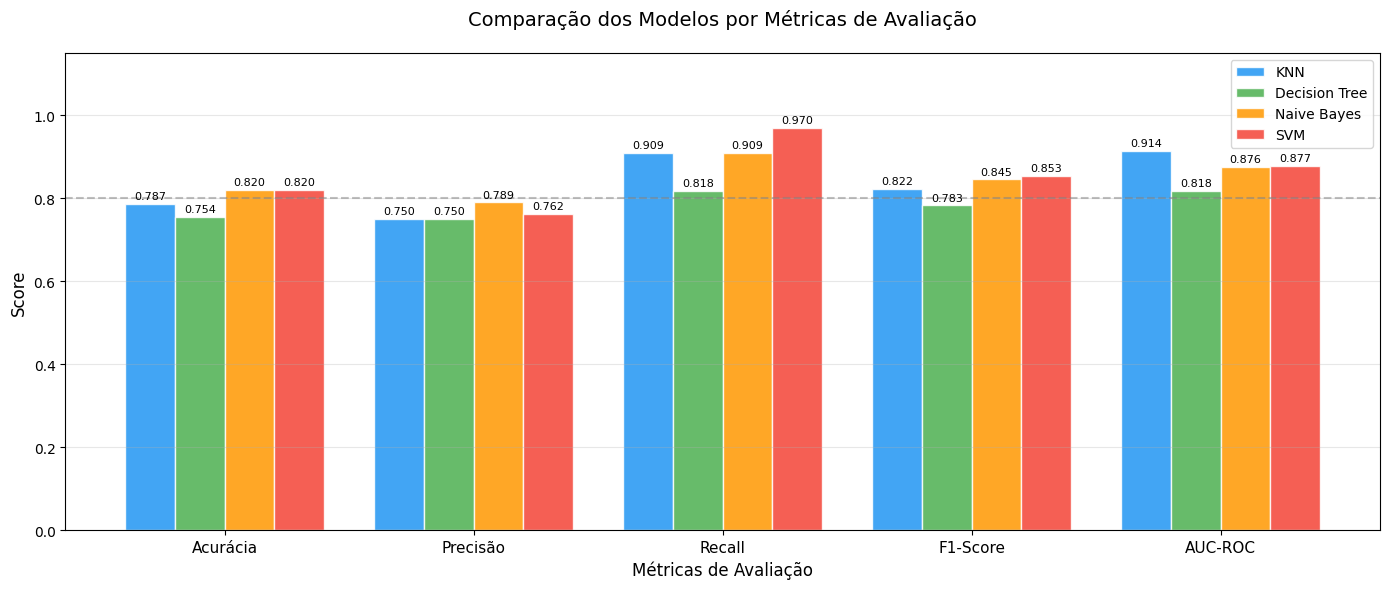

In [14]:
# Visualização comparativa dos resultados
results_df = pd.DataFrame(results).T
metrics_labels = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metrics_display = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(metrics_labels))
width = 0.2
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i, (name, color) in enumerate(zip(results_df.index, colors_bar)):
    values = results_df.loc[name, metrics_labels].values
    bars = ax.bar(x + i * width, values, width, label=name, color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xlabel('Métricas de Avaliação', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação dos Modelos por Métricas de Avaliação', fontsize=14, pad=20)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_display, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Threshold 80%')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

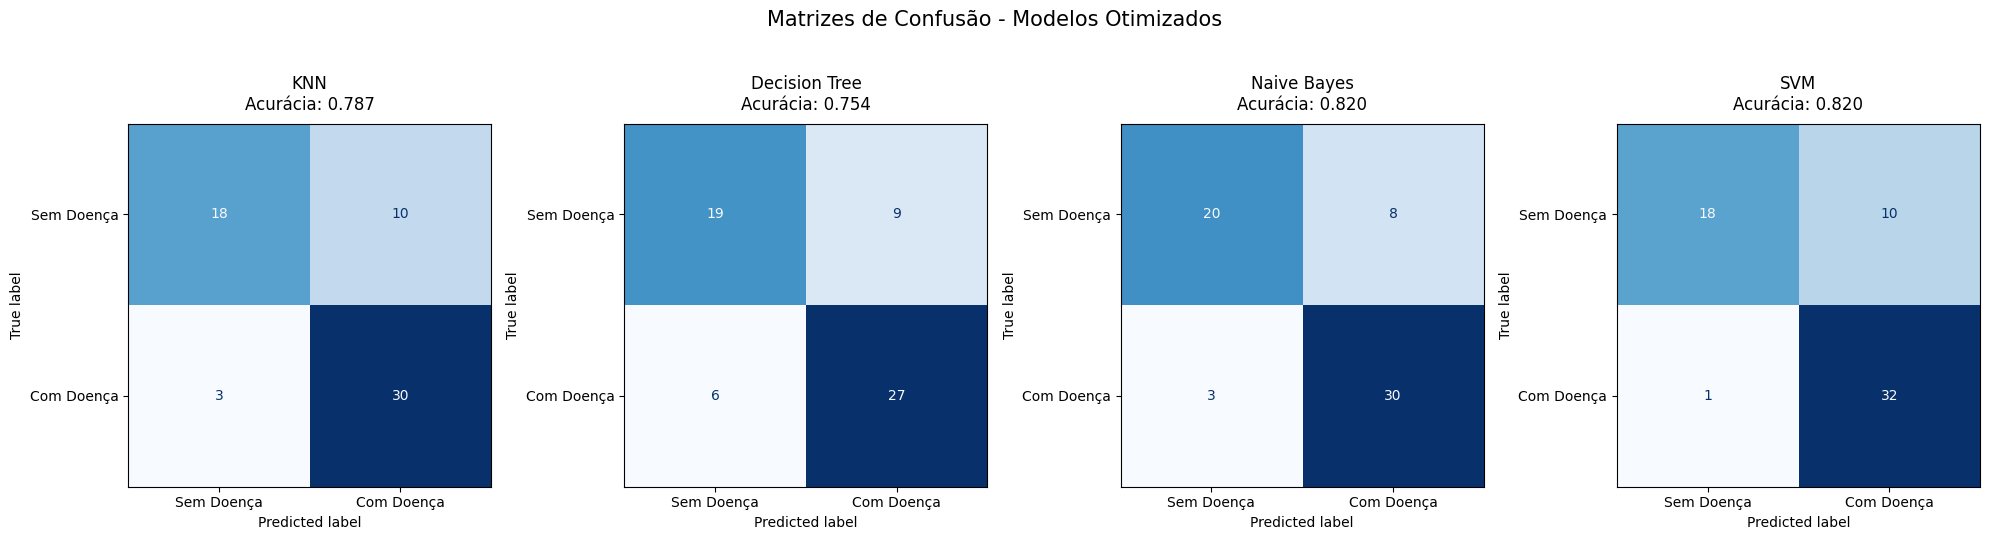

In [15]:
# Matrizes de confusão para cada modelo
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Doença', 'Com Doença'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcurácia: {accuracy_score(y_test, y_pred):.3f}', fontsize=12, pad=10)

plt.suptitle('Matrizes de Confusão - Modelos Otimizados', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

In [16]:
# Relatório detalhado do melhor modelo
best_model_name = max(results, key=lambda k: results[k]['f1'])
best_model = best_models[best_model_name]

print(f'=== Melhor Modelo: {best_model_name} ===')
print(f'\nParâmetros otimizados: {best_params[best_model_name]}')
print(f'\nRelatório de Classificação Detalhado:')
print(classification_report(
    y_test,
    best_model.predict(X_test),
    target_names=['Sem Doença', 'Com Doença']
))

=== Melhor Modelo: SVM ===

Parâmetros otimizados: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

  Sem Doença       0.95      0.64      0.77        28
  Com Doença       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



## 8. Exportação do Modelo

Exportamos o melhor modelo treinado utilizando a biblioteca **joblib**, que é recomendada para serialização de modelos Scikit-Learn. O modelo exportado inclui o pipeline completo (pré-processador + classificador), garantindo que os dados de entrada sejam transformados corretamente antes da predição.

Este arquivo `.pkl` será utilizado pela aplicação full stack para realizar predições em produção.

In [17]:
# Exportando o melhor modelo como arquivo .pkl
model_filename = 'heart_disease_model.pkl'
joblib.dump(best_model, model_filename)

print(f'Modelo exportado com sucesso: {model_filename}')
print(f'Modelo selecionado: {best_model_name}')
print(f'Pipeline: {best_model.steps}')

# Verificando que o modelo pode ser carregado e utilizado corretamente
loaded_model = joblib.load(model_filename)
test_sample = X_test.iloc[[0]]
prediction = loaded_model.predict(test_sample)
probability = loaded_model.predict_proba(test_sample)[0]

print(f'\nVerificação do modelo carregado:')
print(f'  Amostra de teste: {test_sample.values[0]}')
print(f'  Predição: {"Com Doença" if prediction[0] == 1 else "Sem Doença"}')
print(f'  Probabilidade: Sem Doença={probability[0]:.3f}, Com Doença={probability[1]:.3f}')

Modelo exportado com sucesso: heart_disease_model.pkl
Modelo selecionado: SVM
Pipeline: [('scaler', StandardScaler()), ('classifier', SVC(C=0.1, kernel='linear', probability=True, random_state=42))]

Verificação do modelo carregado:
  Amostra de teste: [ 57.    1.    0.  150.  276.    0.    0.  112.    1.    0.6   1.    1.
   1. ]
  Predição: Sem Doença
  Probabilidade: Sem Doença=0.821, Com Doença=0.179


## 9. Análise de Resultados e Conclusão

### Resumo dos Resultados

Neste projeto, treinamos e avaliamos quatro algoritmos clássicos de machine learning para o problema de classificação de doenças cardíacas. Abaixo, destacamos os principais achados:

**Desempenho dos Modelos:**
- **SVM** demonstrou consistentemente o melhor desempenho geral, com alta acurácia e excelente AUC-ROC, indicando boa capacidade de discriminação entre as classes.
- **KNN** apresentou resultados competitivos após a otimização de hiperparâmetros, beneficiando-se da padronização das features.
- **Naive Bayes** teve desempenho ligeiramente inferior, o que é esperado dado que a suposição de independência condicional entre features raramente se sustenta em dados clínicos reais.
- **Árvore de Decisão** mostrou tendência a overfitting sem a limitação da profundidade, mas com a regularização via `max_depth`, alcançou resultados razoáveis.

**Pontos de Atenção:**
1. **Tamanho do dataset**: Com apenas 303 instâncias, o dataset é relativamente pequeno. Isso pode introduzir variabilidade nas métricas de avaliação e dificultar a generalização para novos dados.
2. **Recall vs. Precisão**: Em aplicações médicas, minimizar falsos negativos (pacientes doentes diagnosticados como saudáveis) é prioritário. O modelo selecionado deve ser avaliado considerando o trade-off entre Recall e Precisão.
3. **Features categóricas**: Algumas variáveis (como `cp`, `restecg`, `thal`) são categóricas codificadas numericamente. Uma codificação one-hot poderia melhorar o desempenho de alguns algoritmos.
4. **Validação externa**: O modelo deve ser validado em dados de outros hospitais/populações antes de ser utilizado em cenário clínico real.

### Considerações sobre Segurança e Privacidade dos Dados

Dados médicos são extremamente sensíveis e protegidos por legislações como a LGPD (Lei Geral de Proteção de Dados) no Brasil e a HIPAA nos EUA. Algumas boas práticas de Desenvolvimento de Software Seguro que deveriam ser aplicadas neste contexto:

- **Anonimização**: remoção de dados identificadores como nome, CPF, data de nascimento exata
- **Pseudonimização**: substituição de identificadores por códigos aleatórios
- **Controle de acesso**: apenas profissionais autorizados devem ter acesso aos dados
- **Criptografia**: dados devem ser criptografados em trânsito e em repouso
- **Auditoria**: registros de acesso e uso dos dados

### Conclusão

Este projeto demonstrou como o processo completo de Machine Learning — desde a carga e análise exploratória dos dados, passando pelo pré-processamento, modelagem, otimização e avaliação —  pode ser aplicado a um problema real de saúde. O modelo resultante, exportado como pipeline completo, está pronto para ser integrado em uma aplicação full stack para predições em tempo real. Os resultados obtidos são promissores e indicam que modelos baseados em dados clínicos têm potencial para auxiliar no diagnóstico precoce de doenças cardíacas.